# East Denmark - New API Version

In [1]:
library(renv)
renv::init()


Attaching package: ‘renv’


The following objects are masked from ‘package:stats’:

    embed, update


The following objects are masked from ‘package:utils’:

    history, upgrade


The following objects are masked from ‘package:base’:

    autoload, load, remove




- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
knitr::opts_chunk$set(echo = FALSE,message = FALSE,warning = FALSE)
library(pacman)
pacman::p_load(tidyr,
               dplyr,
               ggplot2,
               httr,
               rpart.plot,
               pushoverr,
               caret,
               zoo,
               glue,
               rPref,
               lubridate)

In [3]:
suppressMessages({ library(pushoverr)
set_pushover_user(user = Sys.getenv("PUSHOVER_USERKEY"))
set_pushover_app(token = Sys.getenv("PUSHOVER_APPKEY"))

})

In [ ]:
# Using new API endpoint: https://api.energidataservice.dk/dataset/DayAheadPrices
# This replaces the old Elspotprices endpoint
# New API provides data in 15-minute intervals (4 records per hour)
api_url = "https://api.energidataservice.dk/dataset/DayAheadPrices?limit=70000&sort=TimeUTC%20DESC&timezone=dk"

api_url = utils::URLencode(api_url)
api_result = httr::GET(api_url)
api_json = rawToChar(api_result$content)
df_raw <- jsonlite::fromJSON(api_json)$records

In [ ]:
# Process the new API data structure
# New API uses:
# - TimeDK instead of HourDK
# - DayAheadPriceDKK instead of SpotPriceDKK
# - DayAheadPriceEUR instead of SpotPriceEUR
# - PriceArea filter for DK2 (East Denmark)
# - Data comes in 15-minute intervals, but we'll aggregate to hourly for compatibility

df <- df_raw %>% 
  filter(PriceArea=="DK2") %>% 
  dplyr::mutate(
    TimeDK_parsed = ymd_hms(TimeDK, tz = "Europe/Copenhagen"),
    HourDK = lubridate::floor_date(TimeDK_parsed, "hour"),  # Aggregate to hourly
    SpotPriceDKK = DayAheadPriceDKK/1000,  # Convert from øre to DKK
    SpotPriceEUR = DayAheadPriceEUR/1000   # Convert from øre to EUR
  ) %>% 
  # Aggregate 15-minute data to hourly averages
  group_by(HourDK, PriceArea) %>% 
  dplyr::summarize(
    SpotPriceDKK = mean(SpotPriceDKK, na.rm = TRUE),
    SpotPriceEUR = mean(SpotPriceEUR, na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  dplyr::mutate(ExchangeRate = SpotPriceDKK/SpotPriceEUR) %>% 
  dplyr::mutate(SpotPriceDKK = ifelse(is.na(SpotPriceDKK), SpotPriceEUR*7.43988, SpotPriceDKK)) %>% 
  # Radius nettarif per 30. september 2023, moms 20%, afgift 87.13 ører.
  dplyr::mutate(transport = case_when(
    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(0,5,by=1) ~ 12.20,
    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(6,16,by=1) ~ 18.31,
    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(17,20,by=1) ~ 47.60,
    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(21,23,by=1) ~ 18.31,
    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(0,5,by=1) ~ 12.20,
    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(6,16,by=1) ~ 36.61,
    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(17,20,by=1) ~ 109.85,
    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(21,23,by=1) ~ 36.61,
    TRUE ~ as.numeric(NA)
  )) %>% 
  dplyr::mutate(transport = transport*0.8) %>%  # uden moms
  dplyr::mutate(elafgift = 72.00) %>% 
  dplyr::mutate(SpotPriceDKK_Total = 1.25*(SpotPriceDKK + transport/100 + elafgift/100)) %>% 
  dplyr::mutate(SpotPriceDKK_Total_SansAfgift = 1.25*(SpotPriceDKK + transport/100)) %>% 
  dplyr::mutate(SpotPriceDKK_Total_SansAfgiftTransport = 1.25*(SpotPriceDKK/100))

In [6]:
df %>% sample_n(50)

TimeUTC,TimeDK,PriceArea,DayAheadPriceEUR,DayAheadPriceDKK,HourDK,SpotPriceDKK,SpotPriceEUR,ExchangeRate,transport,elafgift,SpotPriceDKK_Total,SpotPriceDKK_Total_SansAfgift,SpotPriceDKK_Total_SansAfgiftTransport
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2025-10-04T09:30:00,2025-10-04T11:30:00,DK2,0.10,0.746670,2025-10-04 11:30:00,0.000746670,0.00010,7.4667,29.288,72,1.267033,0.3670333,9.333375e-06
2025-10-14T11:30:00,2025-10-14T13:30:00,DK2,103.54,773.278143,2025-10-14 13:30:00,0.773278143,0.10354,7.4684,29.288,72,2.232698,1.3326977,9.665977e-03
2025-10-12T10:30:00,2025-10-12T12:30:00,DK2,66.27,494.851322,2025-10-12 12:30:00,0.494851322,0.06627,7.4672,29.288,72,1.884664,0.9846642,6.185642e-03
2025-10-08T18:15:00,2025-10-08T20:15:00,DK2,149.85,1118.885040,2025-10-08 20:15:00,1.118885040,0.14985,7.4667,87.880,72,3.397106,2.4971063,1.398606e-02
2025-10-19T21:00:00,2025-10-19T23:00:00,DK2,64.25,479.883250,2025-10-19 23:00:00,0.479883250,0.06425,7.4690,29.288,72,1.865954,0.9659541,5.998541e-03
2025-10-13T10:15:00,2025-10-13T12:15:00,DK2,95.82,715.593342,2025-10-13 12:15:00,0.715593342,0.09582,7.4681,29.288,72,2.160592,1.2605917,8.944917e-03
2025-10-14T02:15:00,2025-10-14T04:15:00,DK2,99.21,740.939957,2025-10-14 04:15:00,0.740939957,0.09921,7.4684,9.760,72,1.948175,1.0481749,9.261749e-03
2025-10-10T16:00:00,2025-10-10T18:00:00,DK2,92.61,691.537399,2025-10-10 18:00:00,0.691537399,0.09261,7.4672,87.880,72,2.862922,1.9629217,8.644217e-03
2025-10-13T18:00:00,2025-10-13T20:00:00,DK2,273.05,2039.164615,2025-10-13 20:00:00,2.039164615,0.27305,7.4681,87.880,72,4.547456,3.6474558,2.548956e-02


## Best Upcoming

Warning message:
“Using one column matrices in `filter()` was deprecated in dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


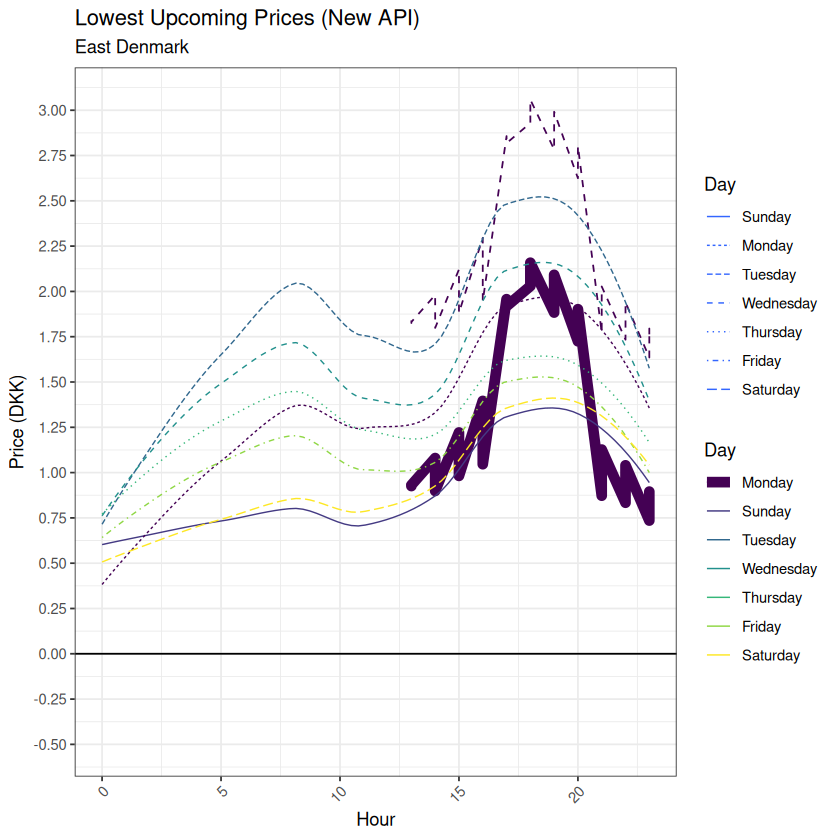

In [7]:
df_previous = df %>% 
  dplyr::mutate(Day=wday(HourDK,label=TRUE,abbr=FALSE),
                Hour=hour(HourDK)) %>% 
  dplyr::mutate(Day=factor(Day)) %>% 
  dplyr::select(Day,
                Hour,
                SpotPriceDKK_Total_SansAfgift)

max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = Sys.time()

lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

p1 = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day=wday(HourDK,label=TRUE,abbr=FALSE)) %>% 
  dplyr::mutate(HourDK=hour(HourDK)) %>% 
  dplyr::mutate(Day=factor(Day)) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift,color=Day)) +
  geom_line(size=3) +
  # geom_line(data=lwr_upr,aes(x=HourDK,y=SpotPriceDKK_Total,color=Cheap),size=2) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total),linetype=2) +
  # geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgiftTransport),linetype=4) +
  geom_hline(yintercept = 0) +
  # scale_x_datetime(date_breaks = "1 hour",date_labels = "%H") +
  scale_y_continuous(limits=c(-0.5,NA),breaks = seq(-1,10,by=0.25)) +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  # geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7)  +
  labs(title="Lowest Upcoming Prices (New API)",
       subtitle="East Denmark",
       x="Hour",
       y="Price (DKK)") +
  # theme(legend.position="null") +
  geom_smooth(data=df_previous,aes(x=Hour,y=SpotPriceDKK_Total_SansAfgift,linetype=Day),alpha=0,size=0.4)
p1

## Best Upcoming, All Day

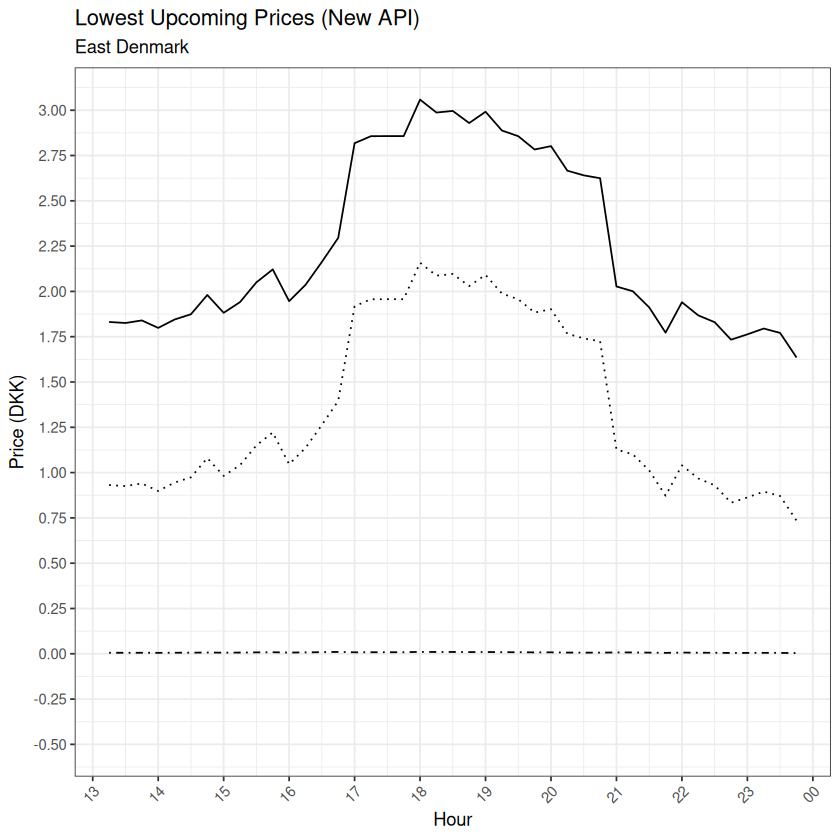

In [8]:
lwr_upr = df %>% 
  filter(HourDK >= Sys.time()) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

p2 = df %>% 
  filter(HourDK >= Sys.time()) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line() +
  # geom_line(data=lwr_upr,aes(x=HourDK,y=SpotPriceDKK_Total,color=Cheap),size=2) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgiftTransport),linetype=4) +
  # geom_hline(yintercept = 0) +
  scale_x_datetime(date_breaks = "1 hour",date_labels = "%H") +
  scale_y_continuous(limits=c(-0.5,NA),breaks = seq(-1,10,by=0.25)) +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  # geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7)  +
  labs(title="Lowest Upcoming Prices (New API)",
       subtitle="East Denmark",
       x="Hour",
       y="Price (DKK)") +
  theme(legend.position="null")
p2

## Best Two-Hour Window

In [9]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = Sys.time()

max_forecast_day

mean_sd = df %>% 
  filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
    filter(hour(HourDK) >= 6) %>% 
    filter(hour(HourDK) <= 17) %>% 
  dplyr::summarize(mean_=mean(SpotPriceDKK_Total_SansAfgift),sd_=sd(SpotPriceDKK_Total_SansAfgift))

df_windows = lapply(seq(2,5),function(window) {
  
  df %>% 
    filter(HourDK >= max_forecast_day) %>% 
    # filter(hour(HourDK) >= 6) %>% 
    # filter(hour(HourDK) <= 17) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift,k = window,fill = NA,align = "left"),
    # dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total,k = window,fill = NA,align = "left"),
                  window=window) %>% 
    dplyr::mutate(rollingsum=rollingsum/window) %>% 
    dplyr::mutate(p_norm=pnorm(rollingsum,mean=mean_sd$mean_,sd=mean_sd$sd_)) %>% 
  dplyr::mutate(p_label=scales::percent(p_norm,accuracy=1)) %>% 
    na.omit
  
})
df_windows = do.call("rbind",df_windows)

# Consider again the preference from above
p <- low(rollingsum) * high(window)

# Calculate the level-value w.r.t. p by using top-all
res <- psel(df_windows, p, top = nrow(df_windows)) %>% filter(.level==min(.level))
res %>% 
  dplyr::select(HourDK,.level,rollingsum,window,p_norm) %>% 
  knitr::kable()

[1] "2025-10-20 CEST"



|HourDK              | .level| rollingsum| window|    p_norm|
|:-------------------|------:|----------:|------:|---------:|
|2025-10-20 04:00:00 |      1|  0.5767221|      2| 0.1068631|
|2025-10-20 04:00:00 |      1|  0.5847979|      3| 0.1094759|
|2025-10-20 03:30:00 |      1|  0.5901663|      4| 0.1112379|
|2025-10-20 03:30:00 |      1|  0.5923229|      5| 0.1119514|

## API Comparison Note

This notebook uses the new **DayAheadPrices** API endpoint which:
- Uses `TimeDK` and `TimeUTC` instead of `HourDK`
- Uses `DayAheadPriceDKK` and `DayAheadPriceEUR` instead of `SpotPriceDKK` and `SpotPriceEUR`
- Provides the same pricing data but with updated field names
- Should be more reliable and future-proof

The rest of the analysis remains the same, but now uses the modern API structure.

## Best Two-Hour Window, All Day

In [ ]:
mean_sd = df %>% 
  filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
    # filter(hour(HourDK) >= 6) %>% 
    # filter(hour(HourDK) <= 17) %>% 
  dplyr::summarize(mean_=mean(SpotPriceDKK_Total_SansAfgift),sd_=sd(SpotPriceDKK_Total_SansAfgift))

df_windows = lapply(seq(2,5),function(window) {
  
  look_up = data.frame(pct=seq(0,1,by=0.01),
           value = df %>% 
    filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift,k = window,fill = NA,align = "left"),
                  window=window) %>% 
    dplyr::mutate(rollingsum=rollingsum/window)  %>% 
    pull(rollingsum) %>% 
    quantile(.,seq(0,1,by=0.01),na.rm=T))
  
  df %>% 
    filter(HourDK >= Sys.time()) %>% 
    # filter(hour(HourDK) >= 6) %>% 
    # filter(hour(HourDK) <= 17) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift,k = window,fill = NA,align = "left"),
                  window=window) %>% 
    dplyr::mutate(rollingsum=rollingsum/window) %>% 
    filter(rollingsum==min(rollingsum,na.rm=T)) %>% 
    # dplyr::mutate(p_norm=pnorm(rollingsum,mean=mean_sd$mean_,sd=mean_sd$sd_)) %>% 
    tidyr::crossing(look_up) %>% 
    filter(rollingsum>=value) %>% 
    filter(pct==max(pct)) %>% 
    dplyr::mutate(p_label=scales::percent(pct,accuracy=1)) %>% 
    na.omit
  
})
df_windows = do.call("rbind",df_windows)

# Consider again the preference from above
p <- low(rollingsum) * high(window)

# Calculate the level-value w.r.t. p by using top-all
res_2 <- psel(df_windows, p, top = nrow(df_windows)) %>% filter(.level==min(.level))
res_2 %>% 
  dplyr::select(HourDK,.level,rollingsum,window,pct) %>% 
  knitr::kable()

In [ ]:
lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line() +
  # geom_line(data=lwr_upr,aes(x=HourDK,y=SpotPriceDKK_Total,color=Cheap),size=2) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3) +
  # geom_hline(yintercept = 0) +
  scale_y_continuous(limits=c(-1,NA),breaks = seq(-1,10,by=0.25)) +
  scale_x_datetime(date_breaks = "1 hour",date_labels = "%H") +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  # geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7)  +
  labs(title="Lowest Upcoming Prices",
       subtitle="East Denmark",
       x="Hour",
       y="Price (DKK)") +
  theme(legend.position="null")